In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict

# Initialize results with float as default value
results = defaultdict(float)

# List of tasks
tasks = ["xnli", "afri-xnli", "udpos", "masakhapos"]

# Aggregate accuracy across all tasks
for task in tasks:
    df = pd.read_csv(f"summary_xlm-roberta-base_{task}.csv")
    
    for _, row in df.iterrows():
        exp = row['exp']
        # Extract accuracy before the "$\pm$"
        acc_str = row['final_eval_avg_accuracy'].split("$\\pm$")[0].strip()
        accuracy = float(acc_str)
        results[exp] += accuracy

# Now average across the 4 tasks
xlmr_averaged_results = {k: v / len(tasks) for k, v in results.items()}

results = defaultdict(float)
# Aggregate accuracy across all tasks
for task in tasks:
    df = pd.read_csv(f"summary_bert-base-multilingual-cased_{task}.csv")
    
    for _, row in df.iterrows():
        exp = row['exp']
        # Extract accuracy before the "$\pm$"
        acc_str = row['final_eval_avg_accuracy'].split("$\\pm$")[0].strip()
        accuracy = float(acc_str)
        results[exp] += accuracy

# Now average across the 4 tasks
mbert_averaged_results = {k: v / len(tasks) for k, v in results.items()}

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Sorted keys (methods)
SORT_COLUMNS = [
    "12_langs", "34_langs",
    "DIVERSE_URIEL_FEATURAL_3", "DIVERSE_URIEL_FEATURAL_7", "DIVERSE_URIEL_FEATURAL_14",
    "LEAST_DIVERSE_URIEL_FEATURAL_3", "LEAST_DIVERSE_URIEL_FEATURAL_7", "LEAST_DIVERSE_URIEL_FEATURAL_14",
    "random_distinct_family_3", "random_distinct_family_7", "random_distinct_family_14",
    "indo_3", "indo_7", "indo_14",
    "high_res", "low_res", "mix_res",
    "random_langs_with_seed_3", "random_langs_with_seed_7", "random_langs_with_seed_14"
]

# Human-readable labels for plotting
LABELS = [
    "Baseline (12 langs)", "Baseline (34 langs)",
    "Featural-Diverse (3)", "Featural-Diverse (7)", "Featural-Diverse (14)",
    "Featural-Least (3)", "Featural-Least (7)", "Featural-Least (14)",
    "Family-Distinct (3)", "Family-Distinct (7)", "Family-Distinct (14)",
    "Indo-European (3)", "Indo-European (7)", "Indo-European (14)",
    "High-Resource (14)", "Low-Resource (14)", "Mixed-Resource (14)",
    "Random (3)", "Random (7)", "Random (14)"
]

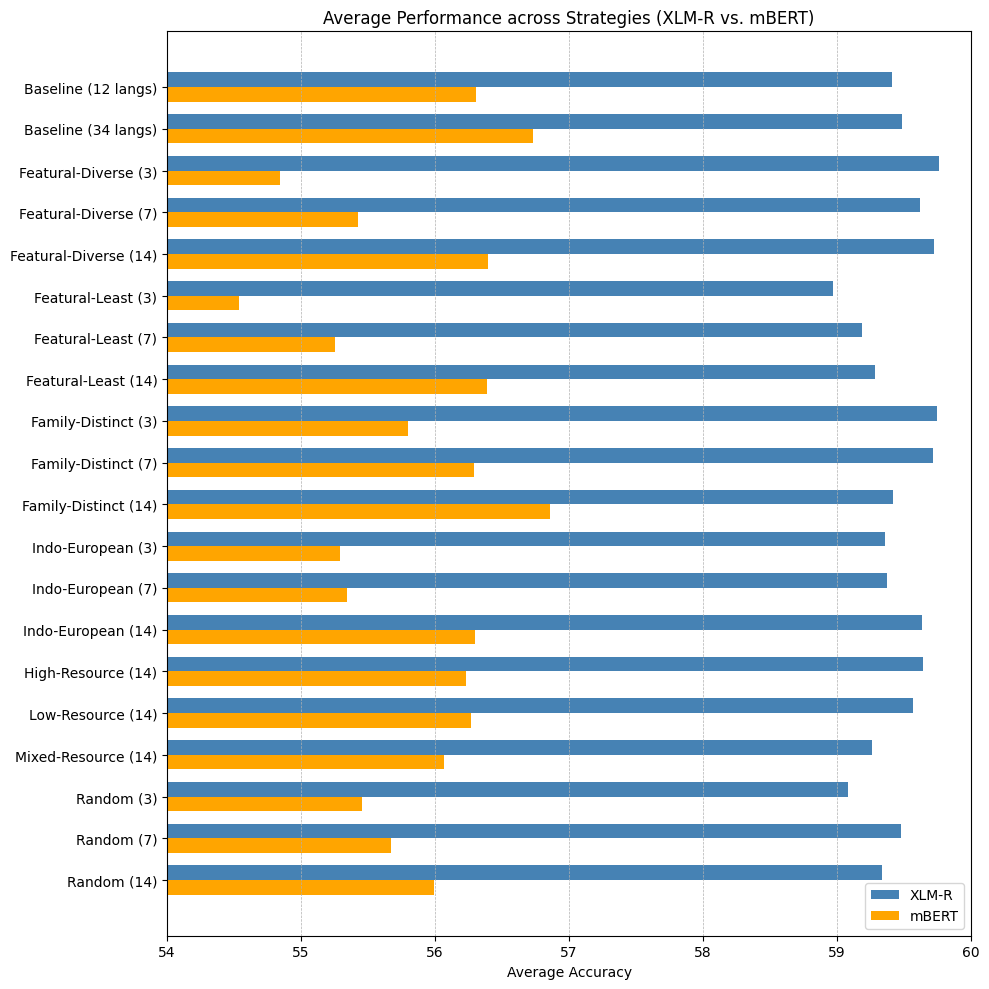

In [3]:
# Extract values in the defined order
xlmr_scores = [xlmr_averaged_results[k] for k in SORT_COLUMNS]
mbert_scores = [mbert_averaged_results[k] for k in SORT_COLUMNS]

# Plot setup
y = np.arange(len(SORT_COLUMNS))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(y - bar_height/2, xlmr_scores, height=bar_height, label='XLM-R', color='steelblue')
ax.barh(y + bar_height/2, mbert_scores, height=bar_height, label='mBERT', color='orange')

# Labels and formatting
ax.set_yticks(y)
ax.set_yticklabels(LABELS)
ax.invert_yaxis()
ax.set_xlabel("Average Accuracy")
ax.set_title("Average Performance across Strategies (XLM-R vs. mBERT)")
ax.set_xlim(54, 60)
ax.legend(loc="lower right")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

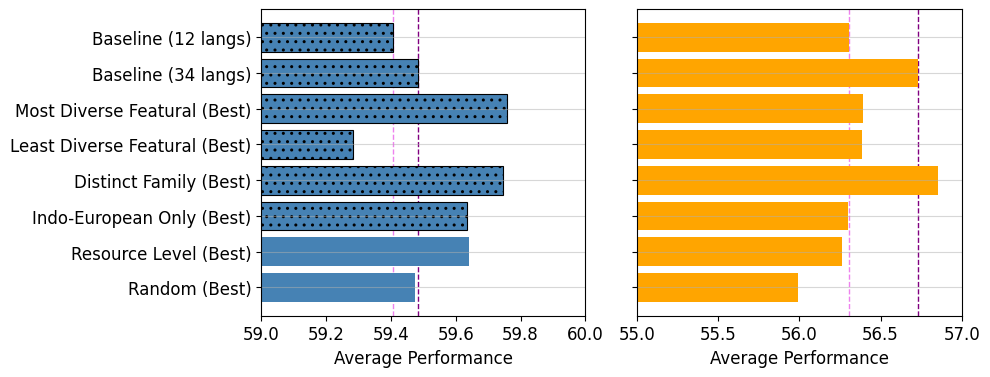

In [4]:
# Labels for display
labels = {
    '12_langs': "Baseline (12 langs)",
    '34_langs': "Baseline (34 langs)",
    'DIVERSE_URIEL_FEATURAL_3': "Most Diverse Featural (Best)",
    'LEAST_DIVERSE_URIEL_FEATURAL_14': "Least Diverse Featural (Best)",
    'random_distinct_family_3': "Distinct Family (Best)",
    'indo_14': "Indo-European Only (Best)",
    'high_res': "Resource Level (Best)",
    'random_langs_with_seed_7': "Random (Best)",
}

# Order for plotting
plot_keys_xlmr = [
    '12_langs', '34_langs',
    'DIVERSE_URIEL_FEATURAL_3',
    'LEAST_DIVERSE_URIEL_FEATURAL_14',
    'random_distinct_family_3',
    'indo_14',
    'high_res',
    'random_langs_with_seed_7',
]

plot_keys_mbert = [
    '12_langs', '34_langs',
    'DIVERSE_URIEL_FEATURAL_14',
    'LEAST_DIVERSE_URIEL_FEATURAL_14',
    'random_distinct_family_14',
    'indo_14',
    'low_res',
    'random_langs_with_seed_14',
]

# Plot setup
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)

y_labels = list(labels.values())
xlmr_vals = [xlmr_averaged_results[k] for k in plot_keys_xlmr]
mbert_vals = [mbert_averaged_results[k] for k in plot_keys_mbert]
y_pos = range(len(plot_keys_mbert))

# XLM-R plot
bars1 = ax1.barh(y_pos, xlmr_vals[::-1], color='steelblue')
ax1.set_xlabel("Average Performance", fontsize=12)
ax1.set_xlim(59, 60)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(y_labels[::-1], fontsize=12)
ax1.tick_params(axis='x', labelsize=12) # Increase x-tick label font size
ax1.grid(axis='y', linestyle='-', alpha=0.5, zorder=0)

for i, key in enumerate(plot_keys_xlmr):
    if not key.endswith("langs"):
        if key.endswith("3"):
            bars1[i].set_hatch('xx') # Apply a hatching pattern (e.g., diagonal lines)
            bars1[i].set_edgecolor('black') # Add a black border for more definition
            bars1[i].set_linewidth(0.8) # Adjust border thickness
        elif key.endswith("7"):
            bars1[i].set_hatch('//') # Apply a hatching pattern (e.g., diagonal lines)
            bars1[i].set_edgecolor('black') # Add a black border for more definition
            bars1[i].set_linewidth(0.8) # Adjust border thickness
        else:
            bars1[i].set_hatch('..') # Apply a hatching pattern (e.g., diagonal lines)
            bars1[i].set_edgecolor('black') # Add a black border for more definition
            bars1[i].set_linewidth(0.8) # Adjust border thickness
        

baseline_12_xlmr = xlmr_averaged_results['12_langs']
baseline_34_xlmr = xlmr_averaged_results['34_langs']

ax1.axvline(x=baseline_12_xlmr, color='violet', linestyle='--', linewidth=1, zorder=0)
ax1.axvline(x=baseline_34_xlmr, color='purple', linestyle='--', linewidth=1, zorder=0)

# mBERT plot
bars2 = ax2.barh(y_pos, mbert_vals[::-1], color='orange')
ax2.set_xlabel("Average Performance", fontsize=12)
ax2.set_xlim(55, 57)
ax2.tick_params(axis='x', labelsize=12) # Increase x-tick label font size
ax2.grid(axis='y', linestyle='-', alpha=0.5, zorder=0)

for i, key in enumerate(plot_keys_mbert):
    if not key.endswith("langs"):
        if key.endswith("3"):
            bars1[i].set_hatch('xx') # Apply a hatching pattern (e.g., diagonal lines)
            bars1[i].set_edgecolor('black') # Add a black border for more definition
            bars1[i].set_linewidth(0.8) # Adjust border thickness
        elif key.endswith("7"):
            bars1[i].set_hatch('//') # Apply a hatching pattern (e.g., diagonal lines)
            bars1[i].set_edgecolor('black') # Add a black border for more definition
            bars1[i].set_linewidth(0.8) # Adjust border thickness
        else:
            bars1[i].set_hatch('..') # Apply a hatching pattern (e.g., diagonal lines)
            bars1[i].set_edgecolor('black') # Add a black border for more definition
            bars1[i].set_linewidth(0.8) # Adjust border thickness

# Add vertical grid lines for baselines in mBERT plot
baseline_12_mbert = mbert_averaged_results['12_langs']
baseline_34_mbert = mbert_averaged_results['34_langs']

ax2.axvline(x=baseline_12_mbert, color='violet', linestyle='--', linewidth=1, zorder=0)
ax2.axvline(x=baseline_34_mbert, color='purple', linestyle='--', linewidth=1, zorder=0)


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

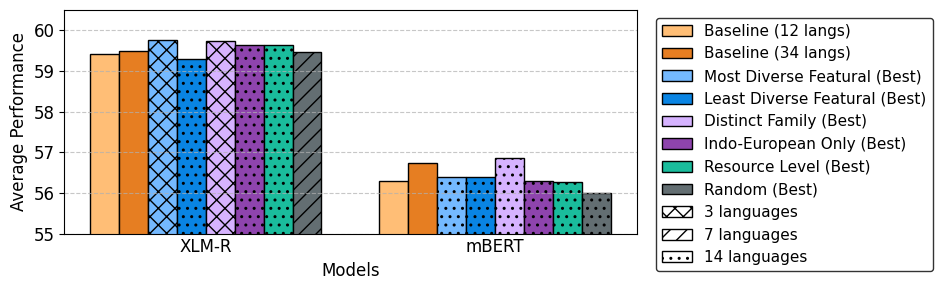

In [5]:
import matplotlib.patches as mpatches

# colors = [
#     '#ffbe76', # Orange
#     '#e67e22', # Pink
#     '#3498db', # Blue
#     '#2ecc71', # Green
#     '#9b59b6', # Purple
#     '#e74c3c', # Red
#     '#1abc9c', # Turquoise
#     '#f1c40f', # Yellow
# ]
colors = [
    '#ffbe76', '#e67e22',  # Baseline
    '#74b9ff', '#0984e3',  # Featural
    '#d6b3ff',  # Light Purple
    '#8e44ad',
    '#1abc9c', # Resource
    '#636e72',  # Random
]

xlmr_hatches = ['', '', 'xx', '..', 'xx', '..', '..', '//']
mbert_hatches = ['', '', '..', '..', '..', '..', '..', '..']
# hatches = {
#     '12_langs': '',
#     '34_langs': '',
#     'DIVERSE_URIEL_FEATURAL_7': '//',
#     'LEAST_DIVERSE_URIEL_FEATURAL_7': 'xx',
#     'random_distinct_family_7': '..',
#     'indo_14': '||',
#     'low_res': 'oo',
#     'random_langs_with_seed_7': '++',
# }


# 3. --- Plot Generation ---
fig, ax = plt.subplots(figsize=(12, 3))

bar_width = 1.0
group_gap = 2  # The space between the XLM-R and mBERT groups

# Define positions for the bars
n_bars = len(plot_keys_mbert)
xlmr_x_positions = np.arange(n_bars)
mbert_x_positions = np.arange(n_bars) + n_bars + group_gap

# --- Plot XLM-R bars ---
for i, key in enumerate(plot_keys_xlmr):
    ax.bar(
        xlmr_x_positions[i],
        xlmr_averaged_results[key],
        width=bar_width,
        color=colors[i],
        hatch=xlmr_hatches[i],
        edgecolor='black',
        capsize=4  # Error bar cap size
    )

# --- Plot mBERT bars ---
for i, key in enumerate(plot_keys_mbert):
    # mBERT keys in your original code sometimes differ (e.g., _14 vs _7)
    # Here we assume the results can be mapped to the same common keys.
    ax.bar(
        mbert_x_positions[i],
        mbert_averaged_results[key],
        width=bar_width,
        color=colors[i],
        hatch=mbert_hatches[i],
        edgecolor='black',
        capsize=4
    )

# 4. --- Legend Creation ---
# Create custom legend handles (patches) to display on top
legend_handles = []
for i, key in enumerate(plot_keys_xlmr):
    handle = mpatches.Patch(
        facecolor=colors[i],
        # hatch=hatches[key],
        edgecolor='black',
        label=labels[key]
    )
    legend_handles.append(handle)
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch='xx', label='3 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch='//', label='7 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch='..', label='14 languages'))


ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    ncol=1,
    fontsize=11,
    frameon=True,
    edgecolor='black'
)

# 5. --- Final Styling ---
# Set Y-axis label and grid
ax.set_ylabel('Average Performance', fontsize=12) # Changed label to be more generic
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Set X-axis labels for the main groups (XLM-R and mBERT)
group_centers = [np.mean(xlmr_x_positions), np.mean(mbert_x_positions)]
ax.set_xticks(group_centers)
ax.set_xticklabels(['XLM-R', 'mBERT'], fontsize=12)
ax.set_xlabel('Models', fontsize=12) # Changed label to be more generic


# Remove the small tick marks on the x-axis for a cleaner look
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', labelsize=12)


# Set Y-axis limits. Adjust if necessary based on your actual data range.
ax.set_ylim(55, 60.5)

# Adjust layout to prevent the legend from being cut off
plt.tight_layout(rect=[0, 0, 0.8, 1]) # rect=[left, bottom, right, top]

# Show the plot
# plt.show()
plt.savefig('main_results_plot.png', dpi=1000)


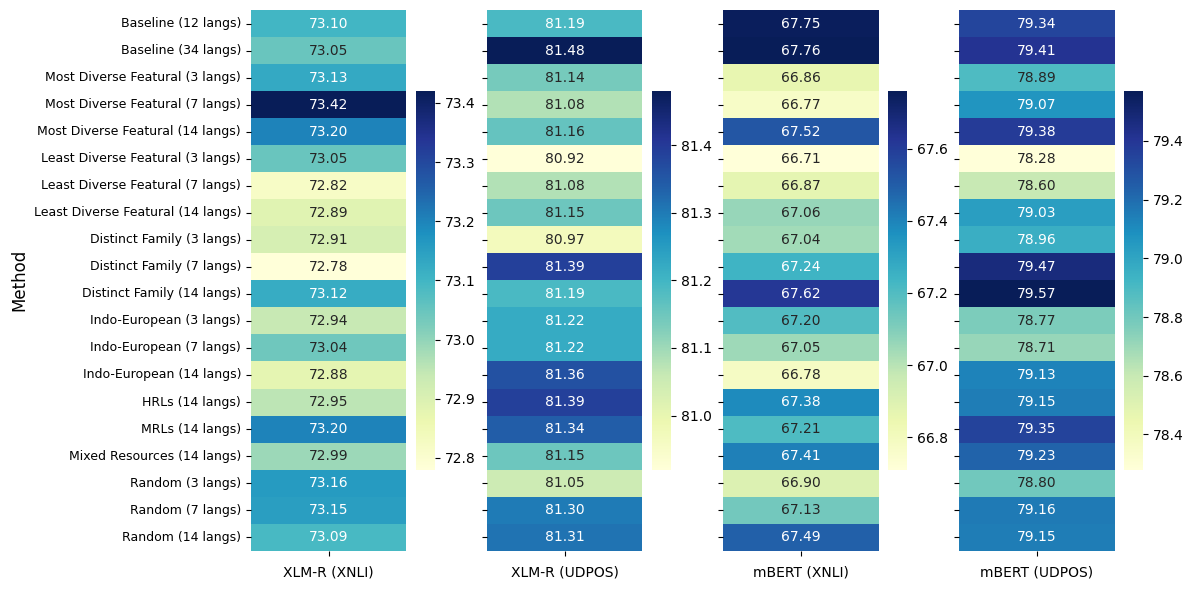

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Assume the dataframe is already loaded
# and contains: 'task', 'exp', 'final_eval_avg_accuracy', 'model'
# where model ∈ {'xlmr', 'mbert'}

def plot_heatmaps(df):
    df = df.copy()

    desired_order = [
        '12_langs',
        '34_langs',
        'DIVERSE_URIEL_FEATURAL_3',
        'DIVERSE_URIEL_FEATURAL_7',
        'DIVERSE_URIEL_FEATURAL_14',
        'LEAST_DIVERSE_URIEL_FEATURAL_3',
        'LEAST_DIVERSE_URIEL_FEATURAL_7',
        'LEAST_DIVERSE_URIEL_FEATURAL_14',
        'random_distinct_family_3',
        'random_distinct_family_7',
        'random_distinct_family_14',
        'indo_3',
        'indo_7',
        'indo_14',
        'high_res',
        'low_res',
        'mix_res',
        'random_langs_with_seed_3',
        'random_langs_with_seed_7',
        'random_langs_with_seed_14',
    ]
    
    label_mapping = {
        '12_langs': 'Baseline (12 langs)',
        '34_langs': 'Baseline (34 langs)',
        'DIVERSE_URIEL_FEATURAL_3': 'Most Diverse Featural (3 langs)',
        'DIVERSE_URIEL_FEATURAL_7': 'Most Diverse Featural (7 langs)',
        'DIVERSE_URIEL_FEATURAL_14': 'Most Diverse Featural (14 langs)',
        'LEAST_DIVERSE_URIEL_FEATURAL_3': 'Least Diverse Featural (3 langs)',
        'LEAST_DIVERSE_URIEL_FEATURAL_7': 'Least Diverse Featural (7 langs)',
        'LEAST_DIVERSE_URIEL_FEATURAL_14': 'Least Diverse Featural (14 langs)',
        'random_distinct_family_3': 'Distinct Family (3 langs)',
        'random_distinct_family_7': 'Distinct Family (7 langs)',
        'random_distinct_family_14': 'Distinct Family (14 langs)',
        'indo_3': 'Indo-European (3 langs)',
        'indo_7': 'Indo-European (7 langs)',
        'indo_14': 'Indo-European (14 langs)',
        'high_res': 'HRLs (14 langs)',
        'low_res': 'MRLs (14 langs)',
        'mix_res': 'Mixed Resources (14 langs)',
        'random_langs_with_seed_3': 'Random (3 langs)',
        'random_langs_with_seed_7': 'Random (7 langs)',
        'random_langs_with_seed_14': 'Random (14 langs)',
    }

    # Calculate height based on number of methods
    plot_height_per_method = 0.3 # Adjust as needed
    fig_height = len(desired_order) * plot_height_per_method

    # Create 1 row, 4 columns of subplots
    fig, axes = plt.subplots(1, 4, figsize=(12, fig_height), sharey=True) # Increased width for 4 plots

    # Define the order of plots in the horizontal layout
    plot_configs = [
        {'model_name': 'xlm-roberta-base', 'task_name': 'XNLI', 'title_prefix': 'XLM-R'},
        {'model_name': 'xlm-roberta-base', 'task_name': 'UDPOS', 'title_prefix': 'XLM-R'},
        {'model_name': 'bert-base-multilingual-cased', 'task_name': 'XNLI', 'title_prefix': 'mBERT'},
        {'model_name': 'bert-base-multilingual-cased', 'task_name': 'UDPOS', 'title_prefix': 'mBERT'},
    ]

    for idx, config in enumerate(plot_configs):
        ax = axes[idx] # Select the correct subplot from the 1D array of axes

        model = config['model_name']
        task = config['task_name']
        title_prefix = config['title_prefix']

        # Filter data for the current model and task
        subset_df = df[(df['model'] == model) & (df['task'] == task)]
        
        # Pivot to get the heatmap format (Method x Task)
        pivot_df = subset_df.pivot(index='exp', columns='task', values='final_eval_avg_accuracy')
        pivot_df = pivot_df.reindex(desired_order).dropna(how='all')
        pivot_df = pivot_df.rename(index=label_mapping)

        # Determine local min/max for this specific heatmap for optimal color differentiation
        local_min = pivot_df.min().min()
        local_max = pivot_df.max().max()

        sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax,
                    vmin=local_min, vmax=local_max, cbar=True, cbar_kws={'shrink': 0.7}) # Each plot gets its own colorbar

        ax.set_xticklabels([])
        ax.set_xlabel(f"{title_prefix} ({task})") # Remove x-label as task name is in title
        
        # # Set y-label only for the very first plot
        if idx == 0:
            ax.set_ylabel("Method", fontsize=12)
        else:
            ax.set_ylabel("") # Remove y-label for subsequent plots since sharey=True
        
        ax.tick_params(axis='x', labelsize=10, rotation=0) # Keep x-labels (task names) horizontal
        ax.tick_params(axis='y', labelsize=9)

    plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust layout to prevent suptitle overlap
    plt.savefig('in_distribution_plot.png', dpi=1000)


# Example usage
list_df = []
for model in ["xlm-roberta-base", "bert-base-multilingual-cased"]:
    for task in ["xnli", "udpos"]:
        df = pd.read_csv(f"summary_{model}_{task}.csv")[['task', 'exp', 'final_eval_avg_accuracy']]
        df['final_eval_avg_accuracy'] = df['final_eval_avg_accuracy'].str.split(' ').str[0].str.strip().astype(float)
        df['task'] = task.upper()
        df['model'] = model
        list_df.append(df)
        
merged_df = pd.concat(list_df)
plot_heatmaps(merged_df)


In [7]:
grouped_df = merged_df.groupby(['exp', 'model'])['final_eval_avg_accuracy'].mean().reset_index()




In [9]:
mbert_df_id = grouped_df[grouped_df['model'] == 'bert-base-multilingual-cased']
mbert_df_id['exp'] = pd.Categorical(mbert_df_id['exp'], categories=SORT_COLUMNS, ordered=True)
mbert_df_id = mbert_df_id.sort_values('exp')  # This line actually performs the sorting
mbert_df_id 

/tmp/ipykernel_35928/2677358195.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mbert_df_id['exp'] = pd.Categorical(mbert_df_id['exp'], categories=SORT_COLUMNS, ordered=True)


,exp,model,final_eval_avg_accuracy
0,12_langs,bert-base-multilingual-cased,73.545
2,34_langs,bert-base-multilingual-cased,73.585
6,DIVERSE_URIEL_FEATURAL_3,bert-base-multilingual-cased,72.875
8,DIVERSE_URIEL_FEATURAL_7,bert-base-multilingual-cased,72.920
4,DIVERSE_URIEL_FEATURAL_14,bert-base-multilingual-cased,73.450
12,LEAST_DIVERSE_URIEL_FEATURAL_3,bert-base-multilingual-cased,72.495
14,LEAST_DIVERSE_URIEL_FEATURAL_7,bert-base-multilingual-cased,72.735
10,LEAST_DIVERSE_URIEL_FEATURAL_14,bert-base-multilingual-cased,73.045
30,random_distinct_family_3,bert-base-multilingual-cased,73.000
32,random_distinct_family_7,bert-base-multilingual-cased,73.355


In [10]:
xlmr_df_id = grouped_df[grouped_df['model'] == 'xlm-roberta-base']
xlmr_df_id['exp'] = pd.Categorical(xlmr_df_id['exp'], categories=SORT_COLUMNS, ordered=True)
xlmr_df_id = xlmr_df_id.sort_values('exp')  # This line actually performs the sorting
xlmr_df_id 

/tmp/ipykernel_35928/1130629565.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xlmr_df_id['exp'] = pd.Categorical(xlmr_df_id['exp'], categories=SORT_COLUMNS, ordered=True)


,exp,model,final_eval_avg_accuracy
1,12_langs,xlm-roberta-base,77.145
3,34_langs,xlm-roberta-base,77.265
7,DIVERSE_URIEL_FEATURAL_3,xlm-roberta-base,77.135
9,DIVERSE_URIEL_FEATURAL_7,xlm-roberta-base,77.250
5,DIVERSE_URIEL_FEATURAL_14,xlm-roberta-base,77.180
13,LEAST_DIVERSE_URIEL_FEATURAL_3,xlm-roberta-base,76.985
15,LEAST_DIVERSE_URIEL_FEATURAL_7,xlm-roberta-base,76.950
11,LEAST_DIVERSE_URIEL_FEATURAL_14,xlm-roberta-base,77.020
31,random_distinct_family_3,xlm-roberta-base,76.940
33,random_distinct_family_7,xlm-roberta-base,77.085


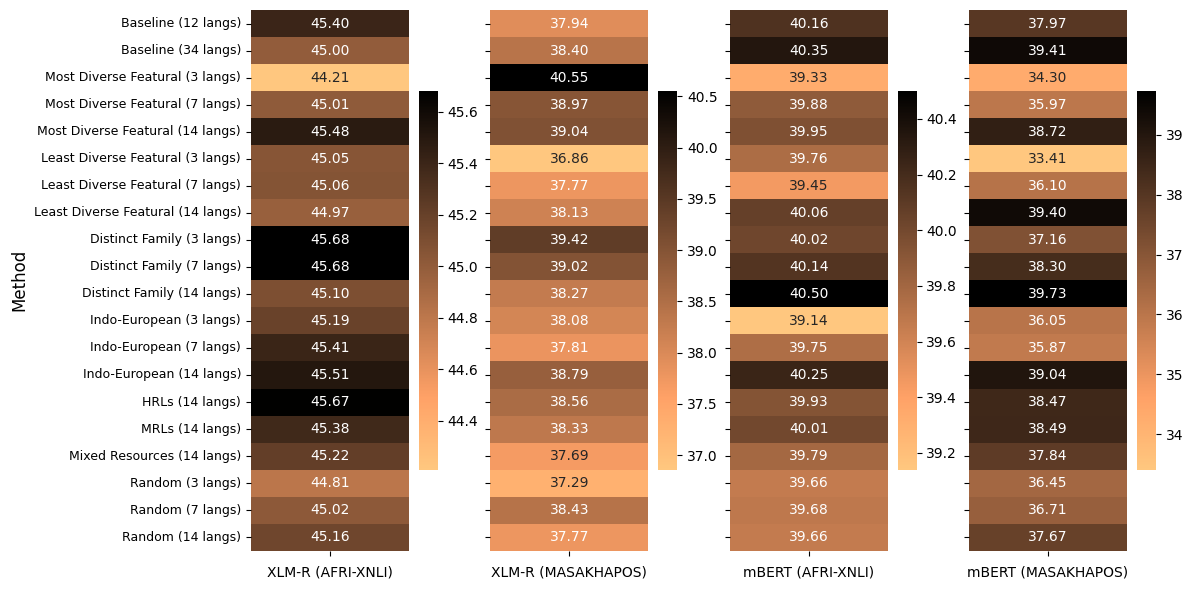

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Assume the dataframe is already loaded
# and contains: 'task', 'exp', 'final_eval_avg_accuracy', 'model'
# where model ∈ {'xlmr', 'mbert'}

def plot_heatmaps(df):
    df = df.copy()

    desired_order = [
        '12_langs',
        '34_langs',
        'DIVERSE_URIEL_FEATURAL_3',
        'DIVERSE_URIEL_FEATURAL_7',
        'DIVERSE_URIEL_FEATURAL_14',
        'LEAST_DIVERSE_URIEL_FEATURAL_3',
        'LEAST_DIVERSE_URIEL_FEATURAL_7',
        'LEAST_DIVERSE_URIEL_FEATURAL_14',
        'random_distinct_family_3',
        'random_distinct_family_7',
        'random_distinct_family_14',
        'indo_3',
        'indo_7',
        'indo_14',
        'high_res',
        'low_res',
        'mix_res',
        'random_langs_with_seed_3',
        'random_langs_with_seed_7',
        'random_langs_with_seed_14',
    ]
    
    label_mapping = {
        '12_langs': 'Baseline (12 langs)',
        '34_langs': 'Baseline (34 langs)',
        'DIVERSE_URIEL_FEATURAL_3': 'Most Diverse Featural (3 langs)',
        'DIVERSE_URIEL_FEATURAL_7': 'Most Diverse Featural (7 langs)',
        'DIVERSE_URIEL_FEATURAL_14': 'Most Diverse Featural (14 langs)',
        'LEAST_DIVERSE_URIEL_FEATURAL_3': 'Least Diverse Featural (3 langs)',
        'LEAST_DIVERSE_URIEL_FEATURAL_7': 'Least Diverse Featural (7 langs)',
        'LEAST_DIVERSE_URIEL_FEATURAL_14': 'Least Diverse Featural (14 langs)',
        'random_distinct_family_3': 'Distinct Family (3 langs)',
        'random_distinct_family_7': 'Distinct Family (7 langs)',
        'random_distinct_family_14': 'Distinct Family (14 langs)',
        'indo_3': 'Indo-European (3 langs)',
        'indo_7': 'Indo-European (7 langs)',
        'indo_14': 'Indo-European (14 langs)',
        'high_res': 'HRLs (14 langs)',
        'low_res': 'MRLs (14 langs)',
        'mix_res': 'Mixed Resources (14 langs)',
        'random_langs_with_seed_3': 'Random (3 langs)',
        'random_langs_with_seed_7': 'Random (7 langs)',
        'random_langs_with_seed_14': 'Random (14 langs)',
    }

    # Calculate height based on number of methods
    plot_height_per_method = 0.3 # Adjust as needed
    fig_height = len(desired_order) * plot_height_per_method

    # Create 1 row, 4 columns of subplots
    fig, axes = plt.subplots(1, 4, figsize=(12, fig_height), sharey=True) # Increased width for 4 plots

    # Define the order of plots in the horizontal layout
    plot_configs = [
        {'model_name': 'xlm-roberta-base', 'task_name': 'AFRI-XNLI', 'title_prefix': 'XLM-R'},
        {'model_name': 'xlm-roberta-base', 'task_name': 'MASAKHAPOS', 'title_prefix': 'XLM-R'},
        {'model_name': 'bert-base-multilingual-cased', 'task_name': 'AFRI-XNLI', 'title_prefix': 'mBERT'},
        {'model_name': 'bert-base-multilingual-cased', 'task_name': 'MASAKHAPOS', 'title_prefix': 'mBERT'},
    ]

    for idx, config in enumerate(plot_configs):
        ax = axes[idx] # Select the correct subplot from the 1D array of axes

        model = config['model_name']
        task = config['task_name']
        title_prefix = config['title_prefix']

        # Filter data for the current model and task
        subset_df = df[(df['model'] == model) & (df['task'] == task)]
        
        # Pivot to get the heatmap format (Method x Task)
        pivot_df = subset_df.pivot(index='exp', columns='task', values='final_eval_avg_accuracy')
        pivot_df = pivot_df.reindex(desired_order).dropna(how='all')
        pivot_df = pivot_df.rename(index=label_mapping)

        # Determine local min/max for this specific heatmap for optimal color differentiation
        local_min = pivot_df.min().min()
        local_max = pivot_df.max().max()

        sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="copper_r", ax=ax,
                    vmin=local_min, vmax=local_max, cbar=True, cbar_kws={'shrink': 0.7}) # Each plot gets its own colorbar

        ax.set_xticklabels([])
        ax.set_xlabel(f"{title_prefix} ({task})") # Remove x-label as task name is in title
        
        # # Set y-label only for the very first plot
        if idx == 0:
            ax.set_ylabel("Method", fontsize=12)
        else:
            ax.set_ylabel("") # Remove y-label for subsequent plots since sharey=True
        
        ax.tick_params(axis='x', labelsize=10, rotation=0) # Keep x-labels (task names) horizontal
        ax.tick_params(axis='y', labelsize=9)

    plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust layout to prevent suptitle overlap
    plt.savefig('out_of_distribution_plot.png', dpi=1000)


# Example usage
list_df = []
for model in ["xlm-roberta-base", "bert-base-multilingual-cased"]:
    for task in ["afri-xnli", "masakhapos"]:
        df = pd.read_csv(f"summary_{model}_{task}.csv")[['task', 'exp', 'final_eval_avg_accuracy']]
        df['final_eval_avg_accuracy'] = df['final_eval_avg_accuracy'].str.split(' ').str[0].str.strip().astype(float)
        df['task'] = task.upper()
        df['model'] = model
        list_df.append(df)
        
merged_df = pd.concat(list_df)
plot_heatmaps(merged_df)


In [12]:
grouped_df = merged_df.groupby(['exp', 'model'])['final_eval_avg_accuracy'].mean().reset_index()

xlmr_df_ood = grouped_df[grouped_df['model'] == 'xlm-roberta-base']
xlmr_df_ood['exp'] = pd.Categorical(xlmr_df_ood['exp'], categories=SORT_COLUMNS, ordered=True)
xlmr_df_ood = xlmr_df_ood.sort_values('exp')  # This line actually performs the sorting
xlmr_df_ood


/tmp/ipykernel_35928/3457897337.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xlmr_df_ood['exp'] = pd.Categorical(xlmr_df_ood['exp'], categories=SORT_COLUMNS, ordered=True)


,exp,model,final_eval_avg_accuracy
1,12_langs,xlm-roberta-base,41.670
3,34_langs,xlm-roberta-base,41.700
7,DIVERSE_URIEL_FEATURAL_3,xlm-roberta-base,42.380
9,DIVERSE_URIEL_FEATURAL_7,xlm-roberta-base,41.990
5,DIVERSE_URIEL_FEATURAL_14,xlm-roberta-base,42.260
13,LEAST_DIVERSE_URIEL_FEATURAL_3,xlm-roberta-base,40.955
15,LEAST_DIVERSE_URIEL_FEATURAL_7,xlm-roberta-base,41.415
11,LEAST_DIVERSE_URIEL_FEATURAL_14,xlm-roberta-base,41.550
31,random_distinct_family_3,xlm-roberta-base,42.550
33,random_distinct_family_7,xlm-roberta-base,42.350


In [13]:
mbert_df_ood = grouped_df[grouped_df['model'] == 'bert-base-multilingual-cased']
mbert_df_ood['exp'] = pd.Categorical(mbert_df_ood['exp'], categories=SORT_COLUMNS, ordered=True)
mbert_df_ood = mbert_df_ood.sort_values('exp')  # This line actually performs the sorting
mbert_df_ood 

/tmp/ipykernel_35928/3454310306.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mbert_df_ood['exp'] = pd.Categorical(mbert_df_ood['exp'], categories=SORT_COLUMNS, ordered=True)


,exp,model,final_eval_avg_accuracy
0,12_langs,bert-base-multilingual-cased,39.065
2,34_langs,bert-base-multilingual-cased,39.880
6,DIVERSE_URIEL_FEATURAL_3,bert-base-multilingual-cased,36.815
8,DIVERSE_URIEL_FEATURAL_7,bert-base-multilingual-cased,37.925
4,DIVERSE_URIEL_FEATURAL_14,bert-base-multilingual-cased,39.335
12,LEAST_DIVERSE_URIEL_FEATURAL_3,bert-base-multilingual-cased,36.585
14,LEAST_DIVERSE_URIEL_FEATURAL_7,bert-base-multilingual-cased,37.775
10,LEAST_DIVERSE_URIEL_FEATURAL_14,bert-base-multilingual-cased,39.730
30,random_distinct_family_3,bert-base-multilingual-cased,38.590
32,random_distinct_family_7,bert-base-multilingual-cased,39.220


In [24]:
mbert_df_ood['scenario'] = "ood"
xlmr_df_ood['scenario'] = "ood"
mbert_df_id['scenario'] = "ind"
xlmr_df_id['scenario'] = "ind"

tab2 = pd.concat([mbert_df_ood, xlmr_df_ood, mbert_df_id, xlmr_df_id])

In [15]:
tab2

,exp,model,final_eval_avg_accuracy,scenario
0,12_langs,bert-base-multilingual-cased,39.065,ood
2,34_langs,bert-base-multilingual-cased,39.880,ood
6,DIVERSE_URIEL_FEATURAL_3,bert-base-multilingual-cased,36.815,ood
8,DIVERSE_URIEL_FEATURAL_7,bert-base-multilingual-cased,37.925,ood
4,DIVERSE_URIEL_FEATURAL_14,bert-base-multilingual-cased,39.335,ood
...,...,...,...,...
25,low_res,xlm-roberta-base,77.270,ind
27,mix_res,xlm-roberta-base,77.070,ind
37,random_langs_with_seed_3,xlm-roberta-base,77.105,ind
39,random_langs_with_seed_7,xlm-roberta-base,77.225,ind


In [ ]:
12_langs	bert-base-multilingual-cased	39.065
2	34_langs	bert-base-multilingual-cased	39.880
6	DIVERSE_URIEL_FEATURAL_3	bert-base-multilingual-cased	36.815
8	DIVERSE_URIEL_FEATURAL_7	bert-base-multilingual-cased	37.925
4	DIVERSE_URIEL_FEATURAL_14	bert-base-multilingual-cased	39.335
12	LEAST_DIVERSE_URIEL_FEATURAL_3	bert-base-multilingual-cased	36.585
14	LEAST_DIVERSE_URIEL_FEATURAL_7	bert-base-multilingual-cased	37.775
10	LEAST_DIVERSE_URIEL_FEATURAL_14	bert-base-multilingual-cased	39.730
30	random_distinct_family_3	bert-base-multilingual-cased	38.590
32	random_distinct_family_7	bert-base-multilingual-cased	39.220
28	random_distinct_family_14	bert-base-multilingual-cased	40.115
20	indo_3	bert-base-multilingual-cased	37.595
22	indo_7	bert-base-multilingual-cased	37.810
18	indo_14	bert-base-multilingual-cased	39.645
16	high_res	bert-base-multilingual-cased	39.200
24	low_res	bert-base-multilingual-cased	39.250
26	mix_res	bert-base-multilingual-cased	38.815
36	random_langs_with_seed_3	bert-base-multilingual-cased	38.055
38	random_langs_with_seed_7	bert-base-multilingual-cased	38.195
34	random_langs_with_seed_14

In [30]:
df = tab2[tab2['exp'].isin(['34_langs', 'DIVERSE_URIEL_FEATURAL_3', 'DIVERSE_URIEL_FEATURAL_7', 'DIVERSE_URIEL_FEATURAL_14',
                           'random_distinct_family_3', 'random_distinct_family_7', 'random_distinct_family_14', 'random_langs_with_seed_14'])]

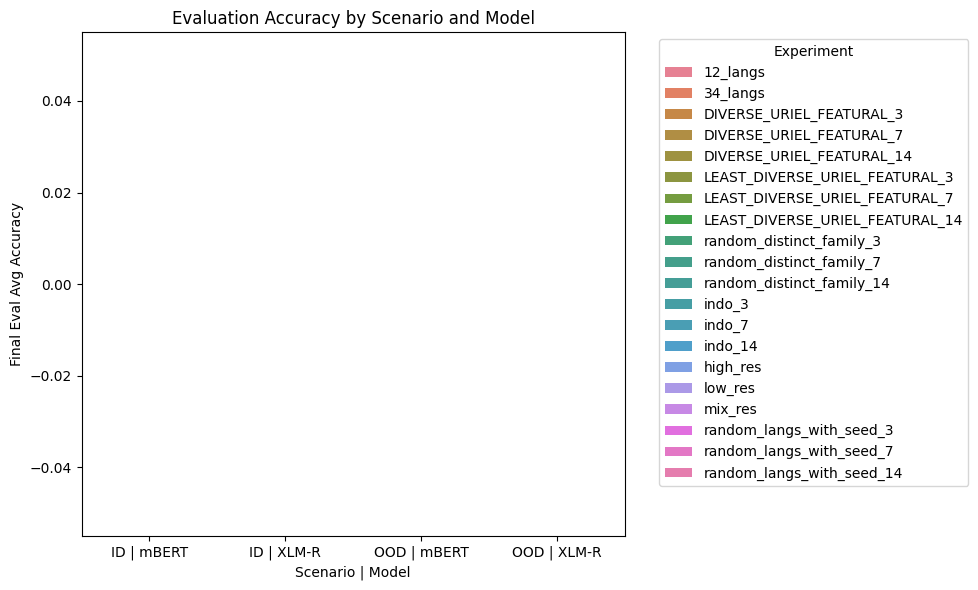

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: sort scenario/model to control order
df["group"] = df["scenario"] + "-" + df["model"]

# Step 1: Create a custom x-axis key (exp within each group)
df["x_label"] = df["scenario"].map({"id": "ID", "ood": "OOD"}) + " | " + df["model"]

# Optional: Sort x_label manually to control order and spacing
desired_order = ["ID | mBERT", "ID | XLM-R", "OOD | mBERT", "OOD | XLM-R"]
df["x_label"] = pd.Categorical(df["x_label"], categories=desired_order, ordered=True)

# Step 2: Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x="x_label",
    y="final_eval_avg_accuracy",
    hue="exp",  # bars for each experiment per group
    dodge=True
)

# Step 3: Beautify
plt.xlabel("Scenario | Model")
plt.ylabel("Final Eval Avg Accuracy")
plt.title("Evaluation Accuracy by Scenario and Model")
plt.legend(title="Experiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Combine model + scenario for clarity (optional if you facet by both)
tab2['model_scenario'] = tab2['model'] + '-' + tab2['scenario']

# Step 2: Use seaborn catplot (FacetGrid for bar plot)
g = sns.catplot(
    data=tab2,
    x="exp",
    y="final_eval_avg_accuracy",
    col="model",
    row="scenario",
    kind="bar",
    height=4,
    aspect=1.5,
    sharey=True  # Or False if accuracy ranges differ
)

# Step 3: Beautify
g.set_xticklabels(rotation=45, ha="right")
g.set_axis_labels("Experiment", "Final Eval Avg Accuracy")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.tight_layout()
plt.show()

In [45]:
id_xlmr

{'34_langs': 77.265,
 'DIVERSE_URIEL_FEATURAL_3': 77.13499999999999,
 'DIVERSE_URIEL_FEATURAL_7': 77.25,
 'DIVERSE_URIEL_FEATURAL_14': 77.18,
 'random_distinct_family_3': 76.94,
 'random_distinct_family_7': 77.08500000000001,
 'random_distinct_family_14': 77.155,
 'random_langs_with_seed_14': 77.2}

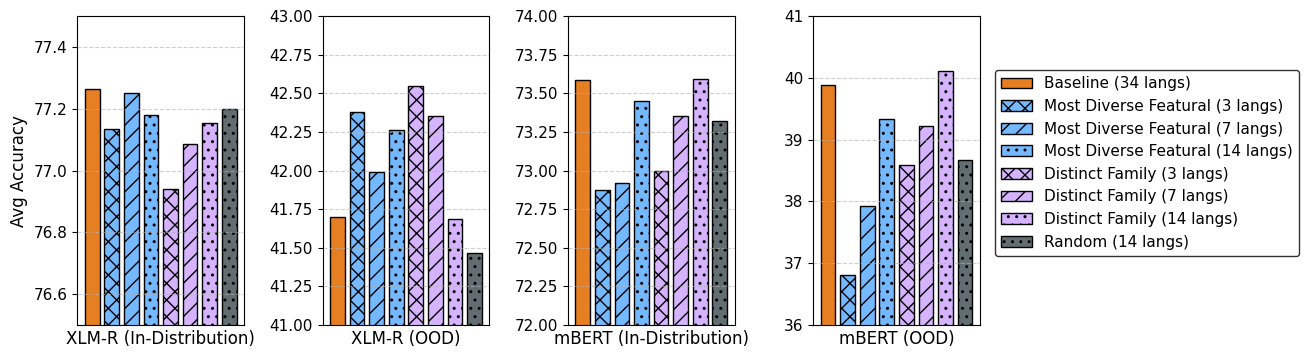

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# === Input Data ===
plot_keys = ['34_langs', 'DIVERSE_URIEL_FEATURAL_3', 'DIVERSE_URIEL_FEATURAL_7', 'DIVERSE_URIEL_FEATURAL_14',
                           'random_distinct_family_3', 'random_distinct_family_7', 'random_distinct_family_14', 'random_langs_with_seed_14']
colors = [
    '#e67e22',  # Baseline
    '#74b9ff', '#74b9ff', '#74b9ff',
    '#d6b3ff',  '#d6b3ff', '#d6b3ff',
    '#636e72',  # Random
]

xlmr_hatches = ['', 'xx', '//', '..', 'xx', '//', '..', '..']
mbert_hatches = ['', 'xx', '//', '..', 'xx', '//', '..', '..']
hatches = ['', 'xx', '//', '..', 'xx', '//', '..', '..']
labels = {
    '34_langs': 'Baseline (34 langs)',
    'DIVERSE_URIEL_FEATURAL_3': 'Most Diverse Featural (3 langs)',
    'DIVERSE_URIEL_FEATURAL_7': 'Most Diverse Featural (7 langs)',
    'DIVERSE_URIEL_FEATURAL_14': 'Most Diverse Featural (14 langs)',
    'random_distinct_family_3': 'Distinct Family (3 langs)',
    'random_distinct_family_7': 'Distinct Family (7 langs)',
    'random_distinct_family_14': 'Distinct Family (14 langs)',
    'random_langs_with_seed_14': 'Random (14 langs)'
}

# Simulated averaged results
id_xlmr = {
    key: df.loc[
        (df['scenario'] == 'ind') & 
        (df['model'] == 'xlm-roberta-base') & 
        (df['exp'] == key),
        'final_eval_avg_accuracy'
    ].values[0]
    for key in labels if not df[
        (df['scenario'] == 'ind') & 
        (df['model'] == 'xlm-roberta-base') & 
        (df['exp'] == key)
    ].empty
}
id_mbert = {
    key: df.loc[
        (df['scenario'] == 'ind') & 
        (df['model'] == 'bert-base-multilingual-cased') & 
        (df['exp'] == key),
        'final_eval_avg_accuracy'
    ].values[0]
    for key in labels if not df[
        (df['scenario'] == 'ind') & 
        (df['model'] == 'bert-base-multilingual-cased') & 
        (df['exp'] == key)
    ].empty
}
ood_xlmr = {
    key: df.loc[
        (df['scenario'] == 'ood') & 
        (df['model'] == 'xlm-roberta-base') & 
        (df['exp'] == key),
        'final_eval_avg_accuracy'
    ].values[0]
    for key in labels if not df[
        (df['scenario'] == 'ood') & 
        (df['model'] == 'xlm-roberta-base') & 
        (df['exp'] == key)
    ].empty
}
ood_mbert = {
    key: df.loc[
        (df['scenario'] == 'ood') & 
        (df['model'] == 'bert-base-multilingual-cased') & 
        (df['exp'] == key),
        'final_eval_avg_accuracy'
    ].values[0]
    for key in labels if not df[
        (df['scenario'] == 'ood') & 
        (df['model'] == 'bert-base-multilingual-cased') & 
        (df['exp'] == key)
    ].empty
}

bar_width = 0.75
gap = 0.5

# === Setup Figure ===
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 4), sharey=False)

# === X positions ===
n_bars = len(plot_keys)
id_xlmr_x = np.arange(n_bars)
id_mbert_x = id_xlmr_x + n_bars + gap
ood_xlmr_x = np.arange(n_bars)
ood_mbert_x = ood_xlmr_x + n_bars + gap

# === Plot Function ===
def plot_group(ax, x_positions, data_dict, color_set, hatch_set):
    for i, key in enumerate(plot_keys):
        ax.bar(
            x_positions[i],
            data_dict[key],
            width=bar_width,
            color=color_set[i],
            hatch=hatch_set[i],
            edgecolor='black'
        )

# === Plot ID ===
plot_group(ax1, id_xlmr_x, id_xlmr, colors, hatches)
ax1.set_xticks([np.mean(id_xlmr_x)])
ax1.set_xticklabels(['XLM-R (In-Distribution)'], fontsize=12)
ax1.set_ylabel('Avg Accuracy', fontsize=12)
ax1.set_ylim(76.5, 77.5)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.tick_params(axis='x', length=0)
ax1.tick_params(axis='y', labelsize=11)

plot_group(ax2, ood_xlmr_x, ood_xlmr, colors, hatches)
ax2.set_xticks([np.mean(ood_xlmr_x)])
ax2.set_xticklabels(['XLM-R (OOD)'], fontsize=12)
ax2.set_ylim(41, 43)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.tick_params(axis='x', length=0)
ax2.tick_params(axis='y', labelsize=11)

plot_group(ax3, id_mbert_x, id_mbert, colors, hatches)
ax3.set_xticks([np.mean(id_mbert_x)])
ax3.set_xticklabels(['mBERT (In-Distribution)'], fontsize=12)
ax3.set_ylim(72, 74)
ax3.grid(axis='y', linestyle='--', alpha=0.6)
ax3.tick_params(axis='x', length=0)
ax3.tick_params(axis='y', labelsize=11)

plot_group(ax4, ood_mbert_x, ood_mbert, colors, hatches)
ax4.set_xticks([np.mean(ood_mbert_x)])
ax4.set_xticklabels(['mBERT (OOD)'], fontsize=12)
ax4.set_ylim(36, 41)
ax4.grid(axis='y', linestyle='--', alpha=0.6)
ax4.tick_params(axis='x', length=0)
ax4.tick_params(axis='y', labelsize=11)

# === Shared Legend ===
legend_handles = [
    mpatches.Patch(facecolor=colors[i], hatch=hatches[i], edgecolor='black', label=labels[plot_keys[i]])
    for i in range(len(plot_keys))
]
fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.00, 0.5),  # just right of the axes, vertically centered
    borderaxespad=0.,
    fontsize=11,
    frameon=True,
    edgecolor='black'
)


# === Final Adjustments ===
plt.tight_layout(rect=[0, 0, 1, 0.92])  # leave space for legend
# plt.show()
plt.savefig("id_ood_side_by_side.png", dpi=1600, bbox_inches='tight')


In [ ]:
Amharic x
Igbo
Shona
Lingala
Ganda
Wolof
Ewe
Xhosa x
Kinyarwanda
Twi
Zulu
Oromo x
Yoruba
Hausa x
Southern Sotho
Swahili x



In [ ]:
Bambara (bam)
Ghomala (bbj)
Ewe (ewe)
Fon (fon)
Hausa (hau) x
Igbo (ibo)
Kinyarwanda (kin)
Luganda (lug)
Dholuo (luo)
Mossi (mos)
Chichewa (nya)
Nigerian Pidgin
chShona (sna)
Kiswahili (swą) x
Setswana (tsn)
Twi (twi)
Wolof (wol)
isiXhosa (xho) x
Yorùbá (yor)
isiZulu (zul)

In [ ]:
Amharic 
Igbo
Shona
Lingala
Ganda
Wolof
Ewe
Xhosa 
Kinyarwanda
Twi
Zulu
Oromo 
Yoruba x
Hausa 
Southern Sotho
Swahili x

In [ ]:
Bambara (bam)
Ghomala (bbj)
Ewe (ewe)
Fon (fon)
Hausa (hau)
Igbo (ibo)
Kinyarwanda (kin)
Luganda (lug)
Dholuo (luo)
Mossi (mos)
Chichewa (nya)
Nigerian Pidgin
chShona (sna)
Kiswahili (swą) x
Setswana (tsn)
Twi (twi)
Wolof (wol)
isiXhosa (xho)
Yorùbá (yor)  x
isiZulu (zul)

In [21]:
xlmr_langs = ['amh', 'xho', 'orm', 'hau', 'swa']
mbert_langs = ['swa', 'yor']

list_dfs = []
for model in ["xlm-roberta-base", "bert-base-multilingual-cased"]:
    for task in ["afri-xnli", "masakhapos"]:
        df = pd.read_csv(f"summary_{model}_{task}.csv")
        df['exp'] = pd.Categorical(df['exp'], categories=SORT_COLUMNS, ordered=True)
        lang_cols = [col for col in df.columns if col.startswith("final_eval_") 
             and col.endswith("_accuracy")
             and 3 <= len(col.split("_")[2]) <= 3
             and col.split("_")[2] not in {"avg", "same"}]
        df = df[['task', 'exp'] + lang_cols]
        for col in lang_cols:
            df[col] = df[col].str.split(' ').str[0].str.strip().astype(float)
        
        allowed_langs = xlmr_langs if model == "xlm-roberta-base" else mbert_langs
        in_dist_cols = [col for col in lang_cols if col.split("_")[2] in allowed_langs]
        ood_cols = [col for col in lang_cols if col.split("_")[2] not in allowed_langs]        
        # Compute per-row mean for OOD and in-distribution
        df['ood_avg'] = df[ood_cols].mean(axis=1)
        df['in_dist_avg'] = df[in_dist_cols].mean(axis=1)
        
        list_dfs.append(df[['exp', 'in_dist_avg', 'ood_avg']])

merged_df = []
for i in range(len(list_dfs)):
    if i == 0:
        merged_df.append(list_dfs[i])
    else:
        merged_df.append(list_dfs[i][['in_dist_avg', 'ood_avg']])
merged_df = pd.concat(merged_df, axis=1)
latex_output = merged_df.to_latex(index=False, float_format="%.2f", column_format="lcccc", bold_rows=False)
print(latex_output)

\begin{tabular}{lcccc}
\toprule
                            exp &  in\_dist\_avg &  ood\_avg &  in\_dist\_avg &  ood\_avg &  in\_dist\_avg &  ood\_avg &  in\_dist\_avg &  ood\_avg \\
\midrule
                       12\_langs &        57.28 &    40.00 &        56.38 &    34.68 &        47.12 &    39.17 &        50.71 &    36.55 \\
                       34\_langs &        56.74 &    39.67 &        57.85 &    34.97 &        47.45 &    39.33 &        51.37 &    38.08 \\
       DIVERSE\_URIEL\_FEATURAL\_3 &        56.13 &    38.79 &        58.01 &    37.47 &        46.06 &    38.37 &        48.95 &    32.67 \\
       DIVERSE\_URIEL\_FEATURAL\_7 &        57.00 &    39.57 &        58.19 &    35.58 &        46.73 &    38.90 &        50.29 &    34.38 \\
      DIVERSE\_URIEL\_FEATURAL\_14 &        57.71 &    39.92 &        57.98 &    35.69 &        46.56 &    39.01 &        50.93 &    37.36 \\
 LEAST\_DIVERSE\_URIEL\_FEATURAL\_3 &        56.44 &    39.87 &        54.62 &    33.72 &        46.10

/tmp/ipykernel_3222113/1155232601.py:33: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_output = merged_df.to_latex(index=False, float_format="%.2f", column_format="lcccc", bold_rows=False)
